In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 13us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 134s 5us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


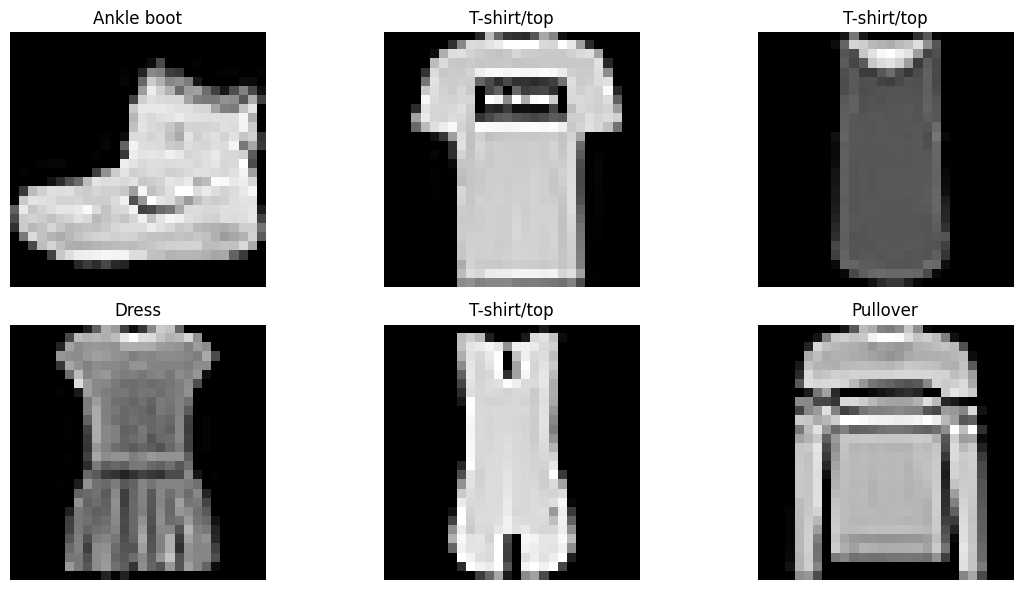

In [3]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [4]:
X_train = X_train / 255.0
X_test  = X_test  / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

print("X_train shape:", X_train.shape)
print("X_test shape:",  X_test.shape)

X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)


In [5]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

C:\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.8037 - loss: 0.5472 - val_accuracy: 0.8531 - val_loss: 0.4078
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.8709 - loss: 0.3617 - val_accuracy: 0.8721 - val_loss: 0.3529
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.8868 - loss: 0.3132 - val_accuracy: 0.8719 - val_loss: 0.3532
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.9006 - loss: 0.2777 - val_accuracy: 0.9004 - val_loss: 0.2807
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.9062 - loss: 0.2563 - val_accuracy: 0.8980 - val_loss: 0.2826


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 365,792 (1.40 MB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 243,862 (952.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8889 - loss: 0.2936
Test loss: 0.2936064898967743
Test accuracy: 0.8888999819755554


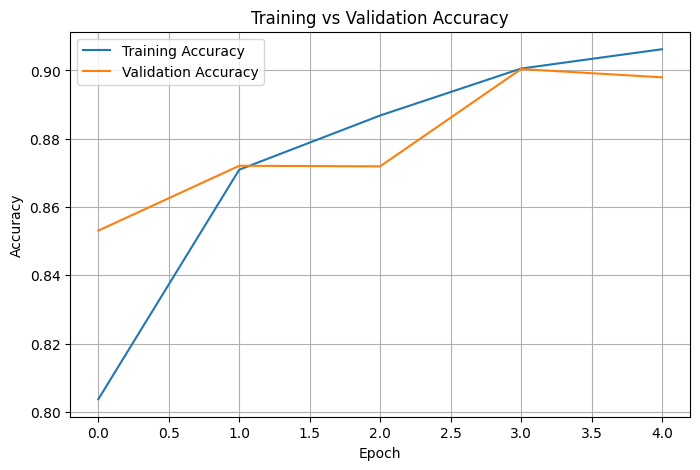

In [7]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print('Test loss:', test_loss)
print('Test accuracy:', test_accuracy)

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step 
Image 0: True = Ankle boot   | Predicted = Ankle boot   | Confidence = 0.9976
Image 1: True = Pullover     | Predicted = Pullover     | Confidence = 0.9989
Image 2: True = Trouser      | Predicted = Trouser      | Confidence = 1.0000
Image 3: True = Trouser      | Predicted = Trouser      | Confidence = 1.0000
Image 4: True = Shirt        | Predicted = Shirt        | Confidence = 0.8885
Image 5: True = Trouser      | Predicted = Trouser      | Confidence = 1.0000
Image 6: True = Coat         | Predicted = Coat         | Confidence = 0.9877
Image 7: True = Shirt        | Predicted = Shirt        | Confidence = 0.9362
Image 8: True = Sandal       | Predicted = Sandal       | Confidence = 0.9947
Image 9: True = Sneaker      | Predicted = Sneaker      | Confidence = 0.9998


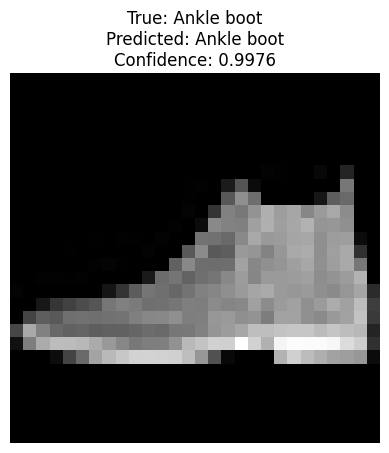

In [12]:
probabilities = model.predict(X_test[:50])
predicted_labels = np.argmax(probabilities, axis=1)

for i in range(10):
    print(f"Image {i}: True = {class_names[y_test[i]]:12s} | Predicted = {class_names[predicted_labels[i]]:12s} | Confidence = {probabilities[i].max():.4f}")

for i in range(20):
    if predicted_labels[i] == y_test[i]:
        correct_idx = i
        break

plt.imshow(X_test[correct_idx].reshape(28, 28), cmap='gray')
plt.title(f"True: {class_names[y_test[correct_idx]]}\nPredicted: {class_names[predicted_labels[correct_idx]]}\nConfidence: {probabilities[correct_idx].max():.4f}")
plt.axis('off')
plt.show()

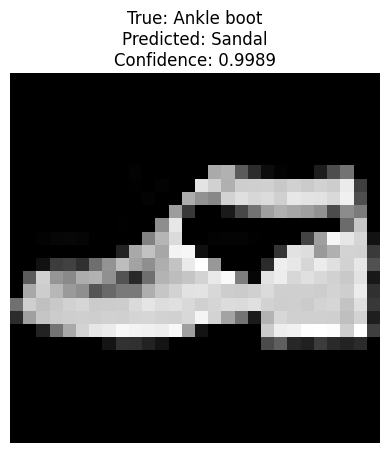

In [14]:
incorrect_idx = None
for i in range(50):
    if predicted_labels[i] != y_test[i]:
        incorrect_idx = i
        break

if incorrect_idx is not None:
    plt.imshow(X_test[incorrect_idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {class_names[y_test[incorrect_idx]]}\nPredicted: {class_names[predicted_labels[incorrect_idx]]}\nConfidence: {probabilities[incorrect_idx].max():.4f}")
    plt.axis('off')
    plt.show()